**Лабораторная работа 1**

**Трудоёмкость алгоритма обработки данных. Моделирование функций активации нейрона**

In [159]:
import numpy as np
import matplotlib.pyplot as plt
import time

_Программа Lab_1_1:_

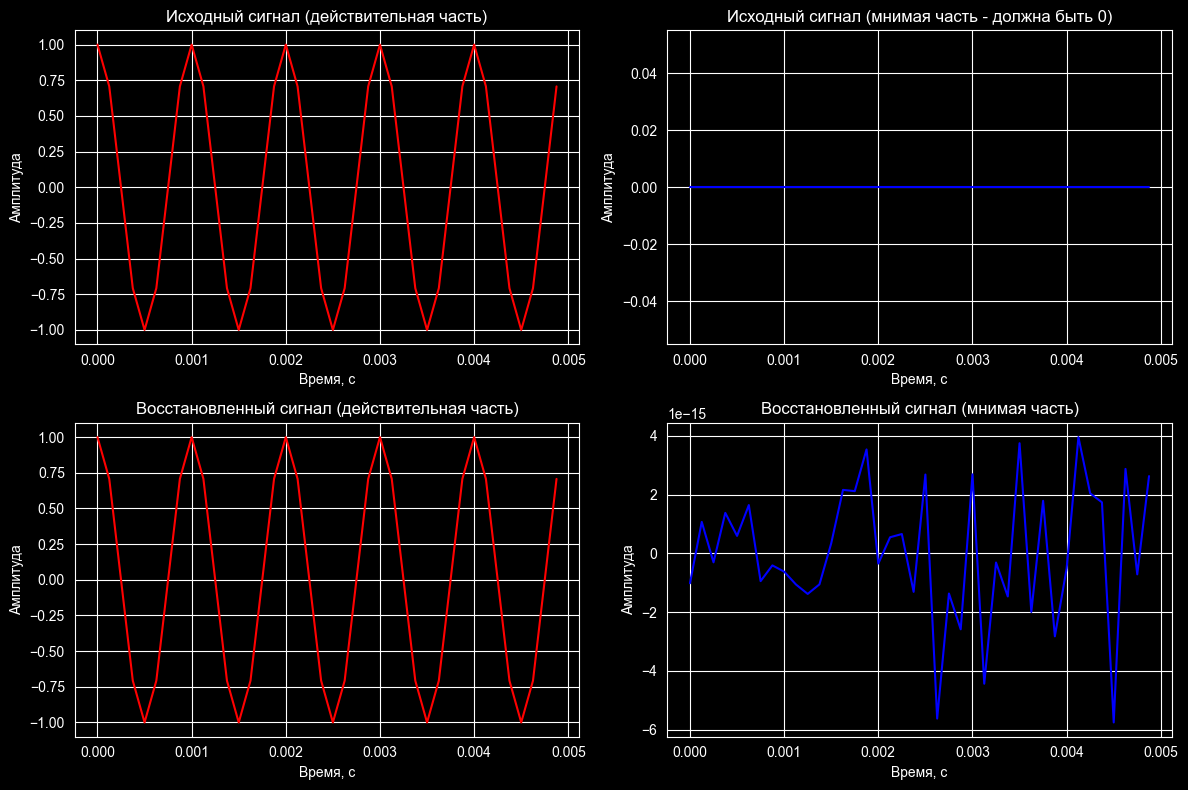

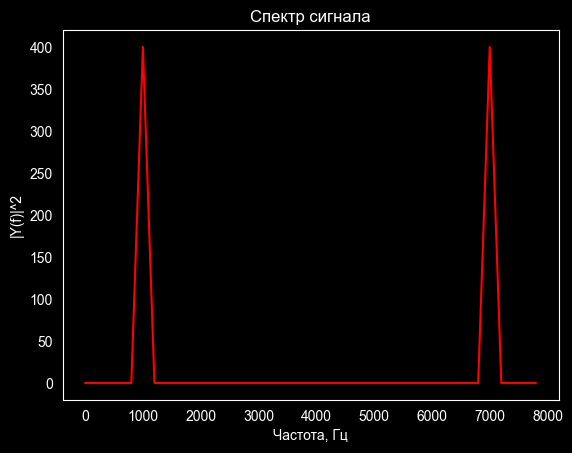

********** Конец работы **********


In [160]:
# Lab_1_1.ipynb (Python версия)
# Дисциплина: Нейронные сети для инженеров
# Лабораторная работа 1
# Обновлённая версия: генерация сигнала, ДПФ, обратное ДПФ и визуализация

## Параметры сигнала
A = float(input('Введите амплитуду сигнала, ед.: '))
f0 = float(input('Введите частоту сигнала, Гц: '))
phi = float(input('Введите фазу сигнала, рад: '))
NT = int(input('Введите количество периодов наблюдения: '))
mvis = int(input('Введите коэффициент увеличения дискретизации: '))

## Дискретизация
T = 1 / f0  # Период сигнала
fdn = 2 * f0  # Частота Найквиста-Котельникова
fdv = mvis * fdn  # Частота дискретизации для визуализации

dt = 1 / fdv  # Интервал дискретизации
Tnab = NT * T  # Время наблюдения

t = np.arange(0, Tnab, dt)  # Вектор времени

# Сигнал
y = A * np.cos(2 * np.pi * f0 * t + phi)

## Прямое ДПФ
N = len(y)
k = np.arange(N)
Ex = np.exp(-1j * 2 * np.pi / N * np.outer(k, k))
Y = y @ Ex

## Обратное ДПФ
Ex_inv = np.exp(1j * 2 * np.pi / N * np.outer(k, k))
ys = (Y @ Ex_inv) / N

## Частотный вектор
ff = k * fdv / N
Y2 = np.abs(Y) ** 2  # Квадрат модуля спектра

## Визуализация сигналов
plt.figure(figsize=(12, 8))

plt.subplot(2, 2, 1)
plt.plot(t, np.real(y), 'r')
plt.title('Исходный сигнал (действительная часть)')
plt.xlabel('Время, с')
plt.ylabel('Амплитуда')

plt.subplot(2, 2, 2)
plt.plot(t, np.imag(y), 'b')
plt.title('Исходный сигнал (мнимая часть - должна быть 0)')
plt.xlabel('Время, с')
plt.ylabel('Амплитуда')

plt.subplot(2, 2, 3)
plt.plot(t, np.real(ys), 'r')
plt.title('Восстановленный сигнал (действительная часть)')
plt.xlabel('Время, с')
plt.ylabel('Амплитуда')

plt.subplot(2, 2, 4)
plt.plot(t, np.imag(ys), 'b')
plt.title('Восстановленный сигнал (мнимая часть)')
plt.xlabel('Время, с')
plt.ylabel('Амплитуда')

plt.tight_layout()
plt.show()

## Визуализация спектра
plt.figure()
plt.plot(ff, Y2, 'r')
plt.title('Спектр сигнала')
plt.xlabel('Частота, Гц')
plt.ylabel('|Y(f)|^2')
plt.grid()
plt.show()

print('********** Конец работы **********')

Используя программу Lab_1_1.ipynb, написать программу Lab_1_2.ipynb, реализующую:

а) дискретизацию и визуализацию функций синуса и косинуса с частотой 2 кГц в двух вариантах: для заданного интервала наблюдения и для заданного количества точек;

In [161]:
A = float(input('Введите амплитуду сигнала, ед.: '))
f0 = 2000  # Частота сигнала, Гц
phi = float(input('Введите фазу сигнала, рад: '))

In [162]:
T = 1 / f0  # Период сигнала
fdn = 2 * f0  # Частота Найквиста-Котельникова
mvis = 4  # Коэффициент увеличения дискретизации
fdv = mvis * fdn  # Частота дискретизации для визуализации
dt = 1 / fdv  # Интервал дискретизации

In [163]:
T_nab = float(input('Введите интервал наблюдения (с): '))
t1 = np.arange(0, T_nab, dt)  # Вектор времени

# Сигнал
y_cos1 = A * np.cos(2 * np.pi * f0 * t1 + phi)
y_sin1 = A * np.sin(2 * np.pi * f0 * t1 + phi)

In [164]:
N_points = int(input('Введите количество точек: '))
t2 = np.arange(0, N_points * dt, dt)

# Сигнал
y_cos2 = A * np.cos(2 * np.pi * f0 * t2 + phi)
y_sin2 = A * np.sin(2 * np.pi * f0 * t2 + phi)

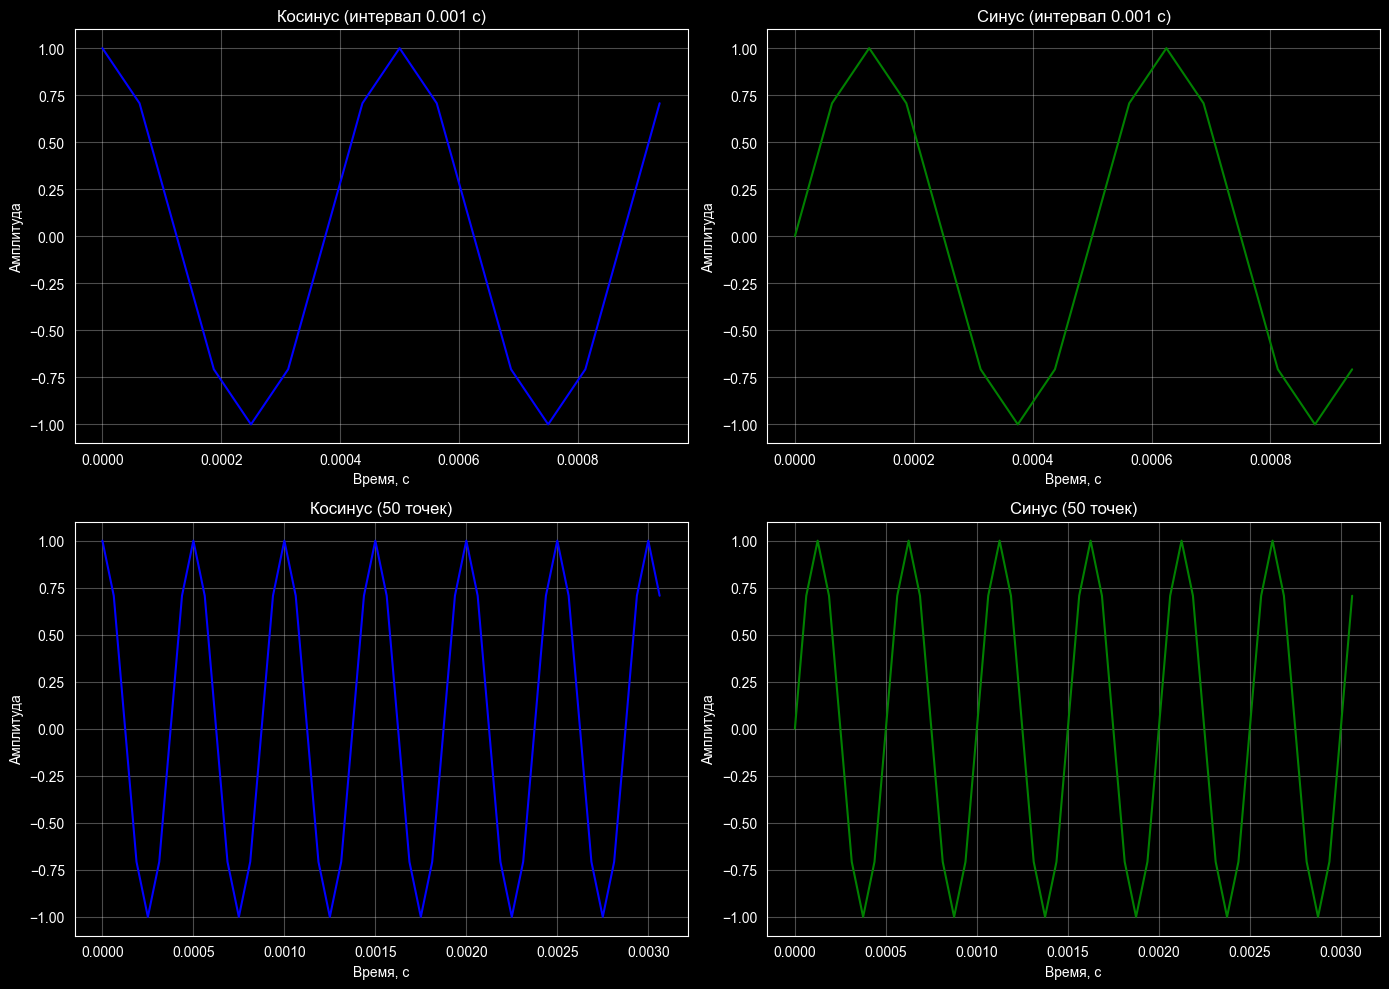

In [165]:
plt.figure(figsize=(14, 10))

plt.subplot(2, 2, 1)
plt.plot(t1, y_cos1, 'b-', alpha=1)
plt.title(f'Косинус (интервал {T_nab} с)')
plt.xlabel('Время, с')
plt.ylabel('Амплитуда')
plt.grid(True, alpha=0.3)

plt.subplot(2, 2, 2)
plt.plot(t1, y_sin1, 'g-', alpha=1)
plt.title(f'Синус (интервал {T_nab} с)')
plt.xlabel('Время, с')
plt.ylabel('Амплитуда')
plt.grid(True, alpha=0.3)

plt.subplot(2, 2, 3)
plt.plot(t2, y_cos2, 'b-', alpha=1)
plt.title(f'Косинус ({N_points} точек)')
plt.xlabel('Время, с')
plt.ylabel('Амплитуда')
plt.grid(True, alpha=0.3)

plt.subplot(2, 2, 4)
plt.plot(t2, y_sin2, 'g-', alpha=1)
plt.title(f'Синус ({N_points} точек)')
plt.xlabel('Время, с')
plt.ylabel('Амплитуда')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

б) вычислить фурьеобразы исходных сигналов с помощью прямого вычисления ДПФ и с помощью ДПФ, реализованного в Python (функция np.fft.fft());

In [166]:
def dpf_direct(y):
    N = len(y)
    k = np.arange(N)
    Ex = np.exp(-1j * 2 * np.pi / N * np.outer(k, k))
    Y = y @ Ex
    return Y

In [167]:
t1 = np.arange(0, T_nab, dt)

cos_orig = A * np.cos(2 * np.pi * f0 * t1 + phi)
sin_orig = A * np.sin(2 * np.pi * f0 * t1 + phi)

Y_cos_direct = dpf_direct(cos_orig)
Y_cos_fft = np.fft.fft(cos_orig)

Y_sin_direct = dpf_direct(sin_orig)
Y_sin_fft = np.fft.fft(sin_orig)

print(f"Максимальное различие для косинуса: {np.max(np.abs(Y_cos_direct - Y_cos_fft)):.2e}")
print(f"Максимальное различие для синуса: {np.max(np.abs(Y_sin_direct - Y_sin_fft)):.2e}")

Максимальное различие для косинуса: 1.12e-14
Максимальное различие для синуса: 1.73e-14


в) визуально сравнить реальные и мнимые части фурье-образов и квадраты их модулей.

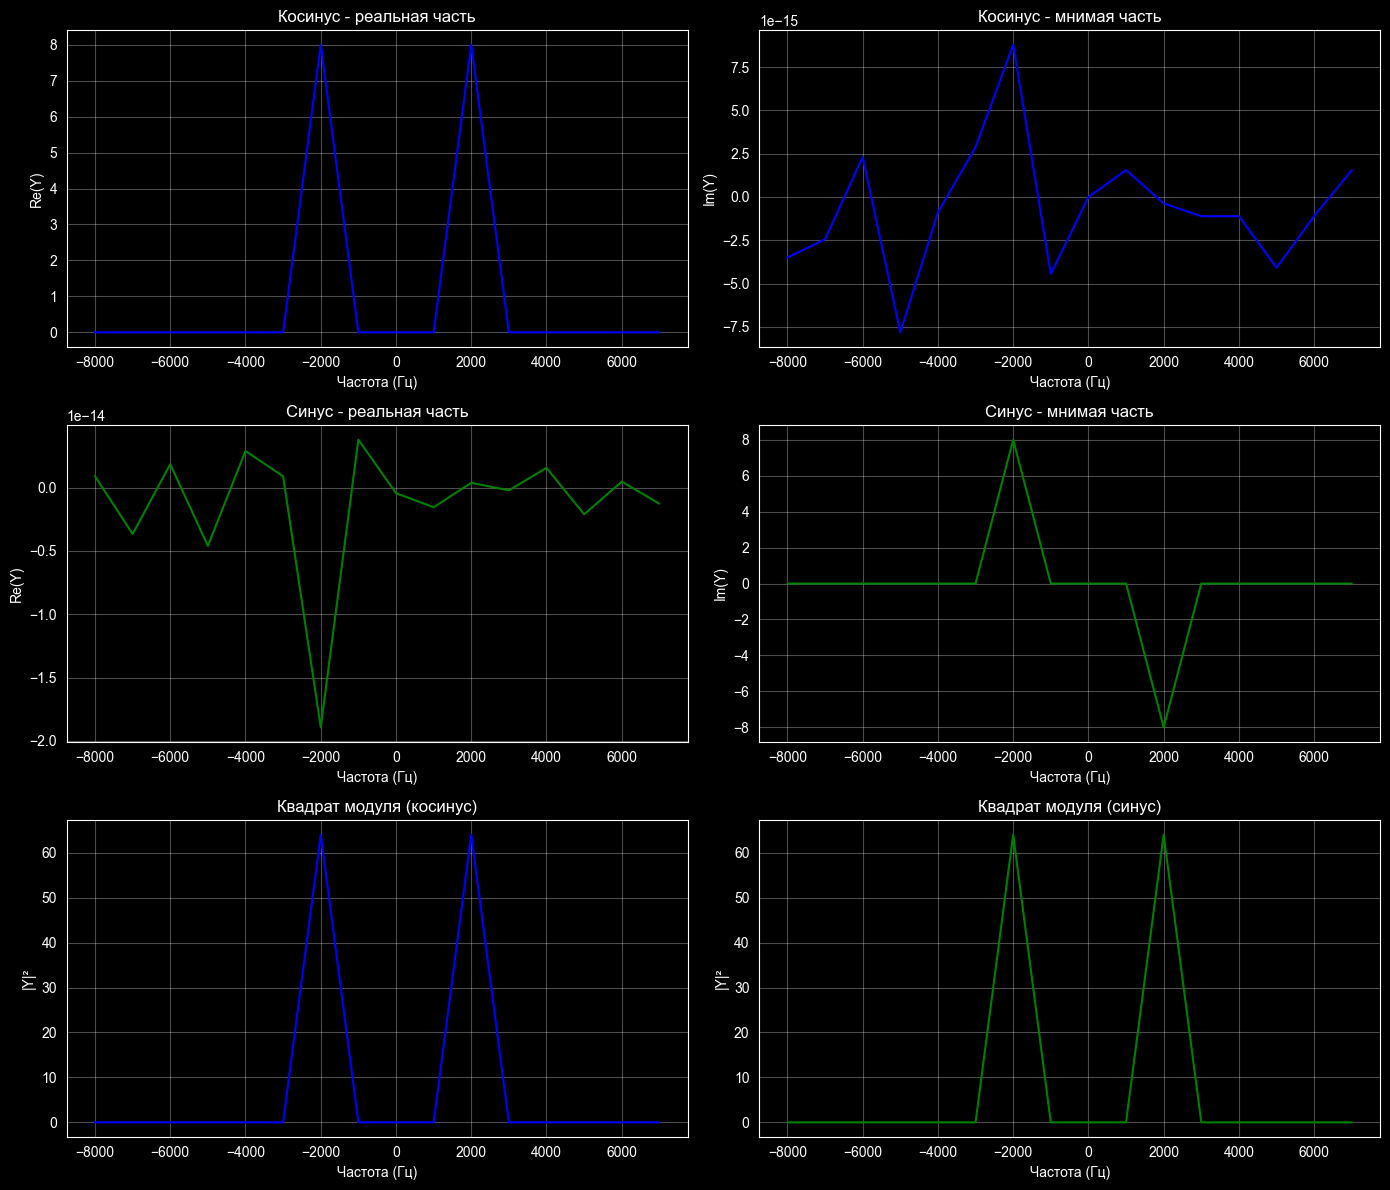

In [168]:
plt.figure(figsize=(14, 12))

freq = np.fft.fftfreq(len(cos_orig), d=dt)
sort_idx = np.argsort(freq)
freq_sorted = freq[sort_idx]

# Косинус - реальная часть
plt.subplot(3, 2, 1)
plt.plot(freq_sorted, np.real(Y_cos_direct)[sort_idx], 'b-')
plt.title('Косинус - реальная часть')
plt.xlabel('Частота (Гц)')
plt.ylabel('Re(Y)')
plt.grid(True, alpha=0.3)

# Косинус - мнимая часть
plt.subplot(3, 2, 2)
plt.plot(freq_sorted, np.imag(Y_cos_direct)[sort_idx], 'b-')
plt.title('Косинус - мнимая часть')
plt.xlabel('Частота (Гц)')
plt.ylabel('Im(Y)')
plt.grid(True, alpha=0.3)

# Синус - реальная часть
plt.subplot(3, 2, 3)
plt.plot(freq_sorted, np.real(Y_sin_direct)[sort_idx], 'g-')
plt.title('Синус - реальная часть')
plt.xlabel('Частота (Гц)')
plt.ylabel('Re(Y)')
plt.grid(True, alpha=0.3)

# Синус - мнимая часть
plt.subplot(3, 2, 4)
plt.plot(freq_sorted, np.imag(Y_sin_direct)[sort_idx], 'g-')
plt.title('Синус - мнимая часть')
plt.xlabel('Частота (Гц)')
plt.ylabel('Im(Y)')
plt.grid(True, alpha=0.3)

# Квадраты модулей
plt.subplot(3, 2, 5)
plt.plot(freq_sorted, (np.abs(Y_cos_direct)[sort_idx])**2, 'b-')
plt.title('Квадрат модуля (косинус)')
plt.xlabel('Частота (Гц)')
plt.ylabel('|Y|²')
plt.grid(True, alpha=0.3)

plt.subplot(3, 2, 6)
plt.plot(freq_sorted, (np.abs(Y_sin_direct)[sort_idx])**2, 'g-')
plt.title('Квадрат модуля (синус)')
plt.xlabel('Частота (Гц)')
plt.ylabel('|Y|²')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

Построить график зависимости времени обработки исходных данных с помощью ДПФ и БПФ, варьируя размерность исходного массива $2^s$ от 128 (s = 7) до 4096 (s = 12)

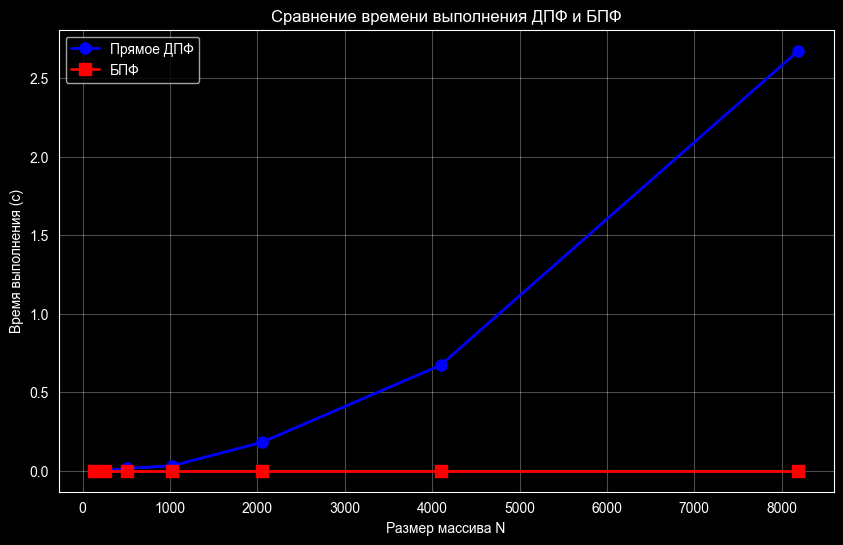

In [169]:
N_values = [2 ** s for s in range(7, 14)]

time_dft, time_fft = [], []

for N in N_values:
    t = np.arange(0, N * dt, dt)
    signal = A * np.cos(2 * np.pi * f0 * t + phi)

    # ДПФ
    start = time.time()
    Y_dft = dpf_direct(signal)
    end = time.time()
    time_dft.append(end - start)

    # БПФ
    start = time.time()
    Y_fft = np.fft.fft(signal)
    end = time.time()
    time_fft.append(end - start)

plt.figure(figsize=(10, 6))
plt.plot(N_values, time_dft, 'bo-', label='Прямое ДПФ', linewidth=2, markersize=8)
plt.plot(N_values, time_fft, 'rs-', label='БПФ', linewidth=2, markersize=8)
plt.xlabel('Размер массива N')
plt.ylabel('Время выполнения (с)')
plt.title('Сравнение времени выполнения ДПФ и БПФ')
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

Написать программу-функцию, реализующую вычисление и отображение функций активации, представленных в разделе 2. Результат представить в виде функции, на вход которой поступает массив входных данных $v$, а также, если требуется, параметр $\alpha$, а в результате ее выполнения производится прорисовка требуемой функции активации.

In [170]:
x = np.arange(-5, 5, 0.05)

*Единичный скачок или пороговая функция, т.е. простая кусочно-линейная функция.*

$$
\left\{
    \begin{matrix}
    y = 0 , v \leq v_o \\
    y = 1 , v > v_o
    \end{matrix}
\right.
$$

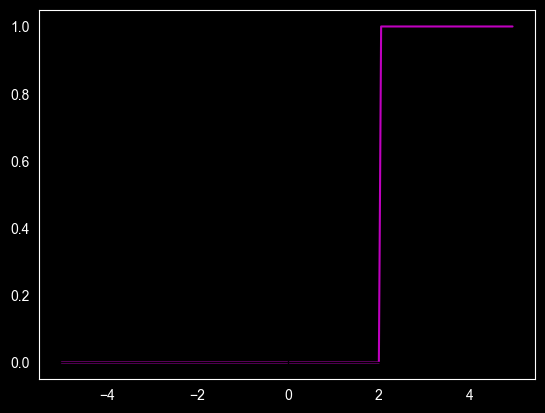

In [171]:
def threshold_function(x, v0):
    plt.plot(x, (x > v0).astype(int), 'm')
    plt.axhline(0, c='k', lw=1)
    plt.axvline(0, c='k', lw=1)
    plt.grid()
    plt.show()


threshold_function(x, 2);

*Линейный порог или гистерезис, т.е. кусочно-линейная функция.*

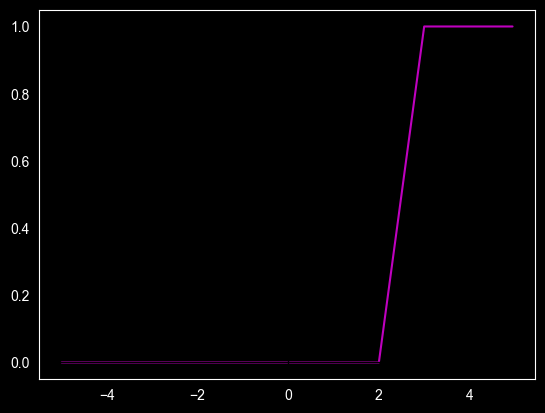

In [172]:
def hysteresis(x, v0, v1):
    plt.plot(x, np.clip((x - v1) / (v0 - v1), 0, 1), 'm')
    plt.axhline(0, c='k', lw=1)
    plt.axvline(0, c='k', lw=1)
    plt.grid()
    plt.show()


hysteresis(x, 3, 2);

*Сигмоидная функция, а именно монотонно возрастающая, всюду дифференцируемая S-образная нелинейная функция с насыщением.*

$${y = \frac{1}{1+exp(- \alpha v)},}$$

*где ${\alpha}$ – параметр наклона сигмоидной функции активации*

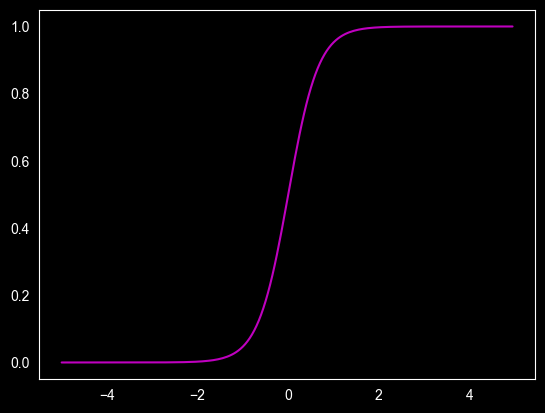

In [173]:
def sigmoid(v, alpha):
    plt.axhline(0, c='k', lw=1)
    plt.axvline(0, c='k', lw=1)
    plt.plot(v, 1 / (1 + np.exp(-alpha * v)), 'm')
    plt.grid()
    plt.show()


sigmoid(x, 3);

*Еще одним примером сигмоидной функции активации является гиперболический тангенс представляемый следующим выражением:*

$${y=th \frac{v}{\alpha}},$$
*где ${\alpha}$ – параметр, влияющий на наклон тангенциальной функции.*

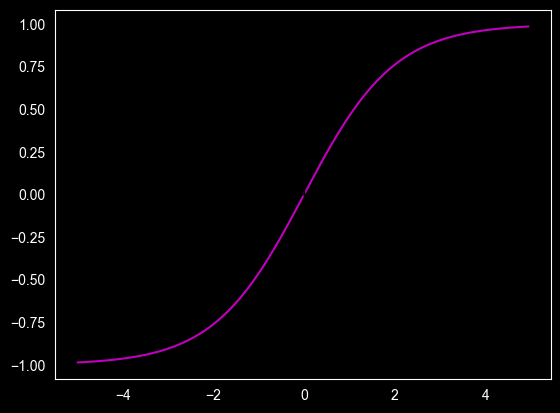

In [174]:
def hyperbolic_tangent(v, alpha):
    plt.plot(v, np.tanh(v / alpha), color='m')
    plt.axhline(0, color='black', linewidth=1)
    plt.axvline(0, color='black', linewidth=1)
    plt.grid()
    plt.show()


hyperbolic_tangent(x, 2);

Вычислите (теоретически и численно) производную сигмоидной функции и представьте на графике.


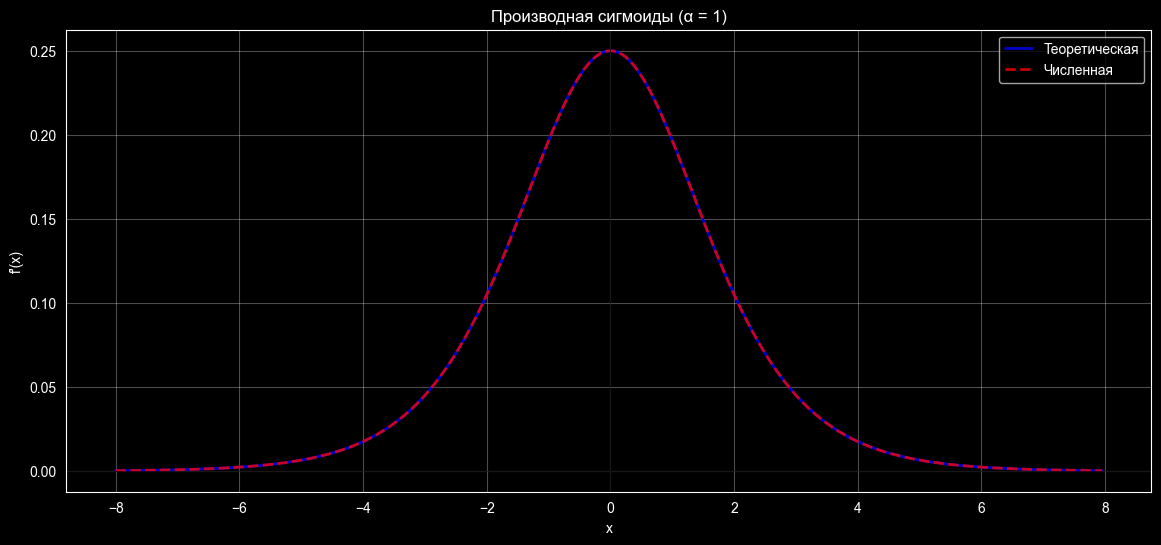

Максимальная разница между теоретической и численной производной: 2.08e-06


In [175]:
def sigmoid(v, alpha):
    return 1 / (1 + np.exp(-alpha * v))


def sigmoid_derivative_theoretical(v, alpha):
    y = sigmoid(v, alpha)
    return alpha * y * (1 - y)


def sigmoid_derivative_numerical(v, alpha, eps=1e-2):
    return (sigmoid(v + eps, alpha) - sigmoid(v - eps, alpha)) / (2 * eps)


alpha = 1
v = np.arange(-8, 8, 0.05)

y_theoretical = sigmoid_derivative_theoretical(v, alpha)
y_num = sigmoid_derivative_numerical(v, alpha)

plt.figure(figsize=(14, 6))

plt.plot(v, y_theor, 'b-', linewidth=2, label='Теоретическая', alpha=0.8)
plt.plot(v, y_num, 'r--', linewidth=2, label='Численная', alpha=0.8)
plt.axhline(0, color='black', linewidth=0.5)
plt.axvline(0, color='black', linewidth=0.5)
plt.grid(True, alpha=0.3)
plt.title(f'Производная сигмоиды (α = {alpha})')
plt.xlabel('x')
plt.ylabel("f'(x)")
plt.legend()
plt.show()

print(f"Максимальная разница между теоретической и численной производной: {np.max(np.abs(y_theor - y_num)):.2e}")